In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

1391034


In [2]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [3]:
import torch
from torch_geometric.data import Data

def build_graph_contact_topK(sequence,score_map,distance_map=None,contact_cutoff=8.0,sep_min=5,k=64):
    N = len(sequence)
    score_map = torch.as_tensor(score_map, dtype=torch.float32)
    score_map = torch.log(score_map + 1.0)

    if distance_map is not None:
        distance_map = torch.as_tensor(distance_map, dtype=torch.float32)

    edge_i = []
    edge_j = []
    edge_attr_list = []
    labels_list = []
    pair_mask_list = []
    edge_mask_list = []

    for i in range(N):
        candidates = torch.arange(N)

        # masks
        mask = (candidates != i) & (torch.abs(candidates - i) >= sep_min)
        candidates = candidates[mask]

        if candidates.numel() == 0:
            continue

        scores = score_map[i, candidates]

        # top-k selection
        if candidates.numel() > k:
            topk_idx = torch.topk(scores, k=k).indices
            candidates = candidates[topk_idx]
            scores = scores[topk_idx]

        edge_i.append(torch.full_like(candidates, i))
        edge_j.append(candidates)
        edge_attr_list.append(scores)



        # pair mask: keep only upper triangle
        pair_mask = i < candidates

        # long-range condition (already enforced, but keep for consistency)
        long_range_ok = torch.abs(candidates - i) >= sep_min

        # labels
        if distance_map is not None:
            dist = distance_map[i, candidates]
            known = torch.isfinite(dist)
            contact = dist <= contact_cutoff
            labels = (known & contact).float()
        else:
            known = torch.ones_like(scores, dtype=torch.bool)
            labels = torch.zeros_like(scores)

        labels_list.append(labels)


        # edge mask = known & long-range
        edge_mask = known & long_range_ok

        pair_mask_list.append(pair_mask)
        edge_mask_list.append(edge_mask)


    edge_i = torch.cat(edge_i)
    edge_j = torch.cat(edge_j)

    edge_index = torch.stack([edge_i, edge_j], dim=0)
    edge_attr = torch.cat(edge_attr_list).unsqueeze(-1)
    y = torch.cat(labels_list).unsqueeze(-1)

  
    edge_mask = torch.cat(edge_mask_list)
    pair_mask = torch.cat(pair_mask_list)

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        edge_mask=edge_mask,
        pair_mask=pair_mask,
        L=N
    )

In [4]:
folder_path = "Data"

all_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']
        data = build_graph_contact_topK(sequence, contact_map_DCA, distance_map)
        all_data.append(data)

from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=1)


train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
#train_loader = DataLoader([all_data[3]], batch_size=1)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import TransformerConv


class TransformerBlock(nn.Module):
    #One graph-transformer block: multi-head attention on graph edges, residual + LayerNorm, FFN + residual + LayerNorm
    def __init__(self, hidden_dim, heads=4, dropout=0.1):
        super().__init__()
        assert hidden_dim % heads == 0, "hidden_dim must be divisible by heads"

        self.attn = TransformerConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim // heads,
            heads=heads,
            concat=True,          # output dim = heads * out_channels = hidden_dim
            beta=True,            # learnable residual gating
            dropout=dropout,
            edge_dim=hidden_dim   # encoded edge_attr dimension
        )

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, 4 * hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * hidden_dim, hidden_dim),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr):
        # Attention block
        h = self.attn(x, edge_index, edge_attr)
        x = self.norm1(x + self.dropout(h))

        # FFN block
        h = self.ffn(x)
        x = self.norm2(x + self.dropout(h))

        return x


class EdgeGraphTransformer(nn.Module):
   
    def __init__(
        self,
        node_in_ch=16,
        edge_in_ch=1,
        hidden_dim=128,
        mlp_hidden_ch=64,
        num_layers=4,
        heads=4,
        dropout=0.1,
    ):
        super().__init__()

        self.node_norm = nn.LayerNorm(node_in_ch)
        self.edge_norm = nn.LayerNorm(edge_in_ch)

        self.node_in = nn.Linear(node_in_ch, hidden_dim)
        self.edge_in = nn.Linear(edge_in_ch, hidden_dim)

        self.layers = nn.ModuleList([
            TransformerBlock(hidden_dim=hidden_dim, heads=heads, dropout=dropout)
            for _ in range(num_layers)
        ])

        # Edge classifier: [h_i, h_j, e_ij] -> logit
        self.edge_head = nn.Sequential(
            nn.Linear(3*hidden_dim, mlp_hidden_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_ch, 1)
        )

        self.edge_mlp = nn.Sequential(
            nn.Linear(3 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, graph):
        x, edge_index, edge_attr = graph.x, graph.edge_index, graph.edge_attr

        # Input projection
        x = self.node_in(self.node_norm(x))
        edge_attr = self.edge_in(self.edge_norm(edge_attr))

        # Transformer encoder
        for layer in self.layers:
            x = layer(x, edge_index, edge_attr)

        # Edge-level prediction
        src, dst = edge_index
        edge_msg = torch.cat([x[src], x[dst], edge_attr], dim=-1)
        edge_attr = edge_attr + self.edge_mlp(edge_msg)
        edge_logits = self.edge_head(edge_msg)  

        return x, edge_logits

In [ ]:
#fa schifo
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GPSConv, GINEConv


class EdgeGPSDenoiser(nn.Module):
    def __init__(
        self,
        node_in_ch=16,      # your sinusoidal PE size
        edge_in_ch=1,       # score map scalar
        channels=128,
        num_layers=4,
        heads=4,
        attn_type="multihead",   # "multihead" or "performer"
        attn_kwargs=None,
        mlp_hidden_ch=64,
        dropout=0.1,
    ):
        super().__init__()
        if attn_kwargs is None:
            attn_kwargs = {}

        # Project node positional encodings to model width
        self.node_in = nn.Sequential(
            nn.Linear(node_in_ch, channels),
            nn.LayerNorm(channels),
        )

        # Project scalar score to model width
        self.edge_in = nn.Sequential(
            nn.Linear(edge_in_ch, channels),
            nn.LayerNorm(channels),
        )

        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            local_mlp = nn.Sequential(
                nn.Linear(channels, channels),
                nn.ReLU(),
                nn.Linear(channels, channels),
            )

            conv = GPSConv(
                channels=channels,
                conv=GINEConv(local_mlp),
                heads=heads,
                dropout=dropout,
                attn_type=attn_type,
                attn_kwargs=attn_kwargs,
            )
            self.convs.append(conv)

        # Edge decoder: [h_i, h_j, e_ij] -> logit
        self.edge_head = nn.Sequential(
            nn.Linear(3 * channels, mlp_hidden_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_ch, 1),
        )

    def forward(self, graph):
        x, edge_index, edge_attr = graph.x, graph.edge_index, graph.edge_attr
        batch = graph.batch

        x = self.node_in(x)
        edge_attr = self.edge_in(edge_attr)

        for conv in self.convs:
            x = conv(x, edge_index, batch=batch, edge_attr=edge_attr)

        src, dst = edge_index
        edge_repr = torch.cat([x[src], x[dst], edge_attr], dim=-1)
        edge_logits = self.edge_head(edge_repr)

        return x, edge_logits

In [6]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [7]:
def average_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_edges = 0
    total_batches= 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, pred_logits = model(batch)
            pred_logits = pred_logits.squeeze(-1)
            true_contacts = batch.y.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss = loss_fn(pred_logits[mask], true_contacts[mask])

            n_edges = mask.sum().item()
            total_loss += loss.item() * n_edges
            total_edges += n_edges
            total_batches += 1

    return total_loss / max(total_edges, 1)


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EdgeGraphTransformer(node_in_ch=16,edge_in_ch=1,hidden_dim=128,mlp_hidden_ch=64,num_layers=4,heads=4,dropout=0.1).to(device)

pos_weight = compute_pos_weight(train_loader, device)
print("pos_weight:", pos_weight.item())
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction='mean')

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
for epoch in range(10000):

    model.train()

    total_loss = 0.0
    total_edges = 0
    for batch in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()

        _, pred_logits = model(batch)

        pred_logits = pred_logits.squeeze(-1)
        true_contacts = batch.y.squeeze(-1)

        mask = batch.edge_mask #& batch.pair_mask

        loss = loss_fn(pred_logits[mask], true_contacts[mask])

        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        optimizer.step()

    train_loss = total_loss / max(total_edges, 1)
    val_loss = average_loss(model, test_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

pos_weight: 5.3882646560668945
Epoch 0: Train Loss=1.1252, Val Loss=1.0938
Epoch 1: Train Loss=1.1007, Val Loss=1.0846
Epoch 2: Train Loss=1.0952, Val Loss=1.0776
Epoch 3: Train Loss=1.0862, Val Loss=1.0735
Epoch 4: Train Loss=1.0783, Val Loss=1.0618
Epoch 5: Train Loss=1.0716, Val Loss=1.0635
Epoch 6: Train Loss=1.0685, Val Loss=1.0553
Epoch 7: Train Loss=1.0601, Val Loss=1.0516
Epoch 8: Train Loss=1.0566, Val Loss=1.0486
Epoch 9: Train Loss=1.0535, Val Loss=1.0407
Epoch 10: Train Loss=1.0484, Val Loss=1.0408
Epoch 11: Train Loss=1.0467, Val Loss=1.0338
Epoch 12: Train Loss=1.0437, Val Loss=1.0337
Epoch 13: Train Loss=1.0405, Val Loss=1.0347
Epoch 14: Train Loss=1.0384, Val Loss=1.0309
Epoch 15: Train Loss=1.0378, Val Loss=1.0316
Epoch 16: Train Loss=1.0339, Val Loss=1.0270
Epoch 17: Train Loss=1.0312, Val Loss=1.0347
Epoch 18: Train Loss=1.0289, Val Loss=1.0238
Epoch 19: Train Loss=1.0247, Val Loss=1.0234
Epoch 20: Train Loss=1.0215, Val Loss=1.0255
Epoch 21: Train Loss=1.0202, Val L

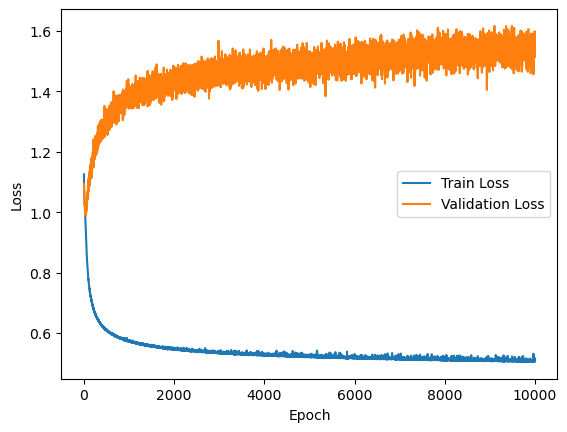

In [9]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [12]:
#loader = DataLoader([train_loader.dataset[10]], batch_size=1)
# loader = DataLoader([test_data[2]], batch_size=1)
# batch = next(iter(loader)).to(device)
k=1

prec=[]
prec_dca=[]
for batch in test_loader:
    batch = batch.to(device)

    #accuracy for a single batch
    with torch.no_grad():
        _, pred_logits = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))
        scores_dca = batch.edge_attr.squeeze(-1)  # DCA scores

    mask = batch.edge_mask & batch.pair_mask
    scores = scores[mask]
    scores_dca = scores_dca[mask]
    true_contacts = batch.y.squeeze(-1)[mask]

    L = batch.L
    topk = int(k * L)

    topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices
    topk_idx_dca = torch.topk(scores_dca, k=min(topk, scores_dca.numel())).indices

    topk_true = true_contacts[topk_idx]
    topk_true_dca = true_contacts[topk_idx_dca]

    num_correct = topk_true.sum()
    precision = (num_correct / len(topk_true)).item()
    prec.append(precision)

    num_correct_dca = topk_true_dca.sum()
    precision_dca = (num_correct_dca / len(topk_true_dca)).item()
    prec_dca.append(precision_dca)


print(f"Precision of the GNN: {np.mean(prec)}")
print(f"Precision of the DCA: {np.mean(prec_dca)}")

Precision of the GNN: 0.49874603217840197
Precision of the DCA: 0.6370507525205612


Validation ROC AUC GNN: 0.9677563820476655
Validation ROC AUC DCA: 0.6649207809073047


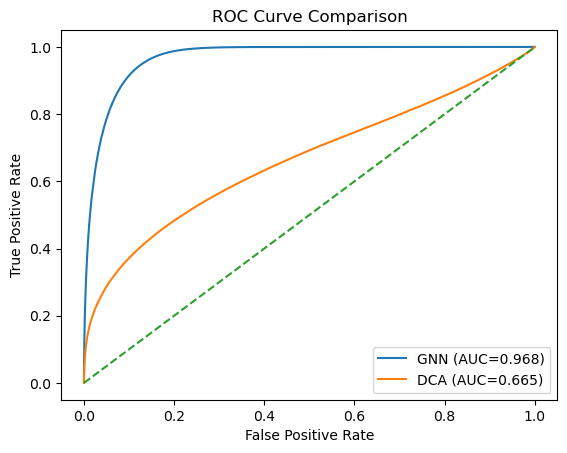

In [14]:
from sklearn.metrics import roc_curve, auc

model.eval()

all_labels = []

all_scores = []
all_scores_dca = []

with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(device)

        _, pred_logits = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))
        dca_scores = batch.edge_attr.squeeze(-1)

        mask = batch.edge_mask & batch.pair_mask

        true_contacts = batch.y.squeeze(-1)[mask]
        y_score = scores[mask]

        all_labels.append(true_contacts.cpu())
        all_scores.append(y_score.cpu())
        all_scores_dca.append(dca_scores[mask].cpu())

# concatenate all batches
all_labels = torch.cat(all_labels).numpy()
all_scores = torch.cat(all_scores).numpy()
all_scores_dca = torch.cat(all_scores_dca).numpy()

# compute ROC
fpr, tpr, _ = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)

fpr_dca, tpr_dca, _ = roc_curve(all_labels, all_scores_dca)
roc_auc_dca = auc(fpr_dca, tpr_dca)

print("Validation ROC AUC GNN:", roc_auc)
print("Validation ROC AUC DCA:", roc_auc_dca)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")
plt.plot(fpr_dca, tpr_dca, label=f"DCA (AUC={roc_auc_dca:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

PR AUC GNN: 0.8376002809042881
PR AUC DCA: 0.3983155470376311


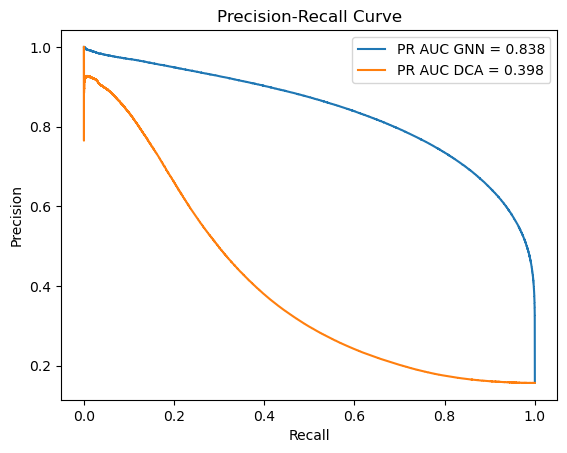

In [15]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_labels, all_scores)
pr_auc = auc(recall, precision)

precision_dca, recall_dca, _ = precision_recall_curve(all_labels, all_scores_dca)
pr_auc_dca = auc(recall_dca, precision_dca)


print("PR AUC GNN:", pr_auc)
print("PR AUC DCA:", pr_auc_dca)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot(recall_dca, precision_dca, label=f"PR AUC DCA = {pr_auc_dca:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [16]:
#We want the precision for each graph to see the distribution
def precision_at_kL_per_graph(batch, pred_logits, k):
    scores = torch.sigmoid(pred_logits.squeeze(-1))
    y_true = batch.y.squeeze(-1)

    mask = batch.edge_mask & batch.pair_mask

    scores = scores[mask]
    y_true = y_true[mask]

    edge_batch = batch.batch[batch.edge_index[0]][mask]

    precisions = []


    for g in edge_batch.unique():
        g_mask = edge_batch == g

        g_scores = scores[g_mask]
        g_true = y_true[g_mask]

        L = batch.L[g].item() if isinstance(batch.L, torch.Tensor) else batch.L

        kL = int(k * L)
        kL = min(kL, g_scores.numel())

        if kL == 0:
            continue

        topk_idx = torch.topk(g_scores, kL).indices
        topk_true = g_true[topk_idx]

        precision = topk_true.float().mean().item()
        precisions.append(precision)
    
    return precisions

#the same but for dca
def precision_at_kL_dca_per_graph(batch, k):
    scores = batch.edge_attr.squeeze(-1)  # DCA scores
    y_true = batch.y.squeeze(-1)

    mask = batch.edge_mask & batch.pair_mask

    scores = scores[mask]
    y_true = y_true[mask]

    edge_batch = batch.batch[batch.edge_index[0]][mask]

    precisions = []

    for g in edge_batch.unique():
        g_mask = edge_batch == g

        g_scores = scores[g_mask]
        g_true = y_true[g_mask]

        L = batch.L[g].item() if isinstance(batch.L, torch.Tensor) else batch.L

        kL = int(k * L)
        kL = min(kL, g_scores.numel())

        if kL == 0:
            continue

        topk_idx = torch.topk(g_scores, kL).indices
        topk_true = g_true[topk_idx]

        precision = topk_true.float().mean().item()
        precisions.append(precision)

    return precisions

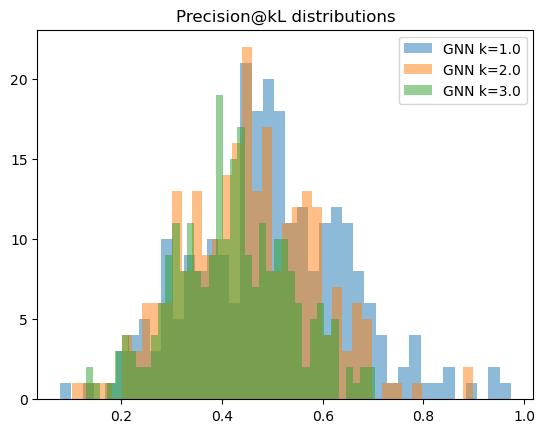

In [19]:
k_values = [1.0,2.0,3.0]

results = {k: [] for k in k_values}
results_dca = {k: [] for k in k_values}

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, pred_logits = model(batch)

        for k in k_values:
            vals= precision_at_kL_per_graph(batch, pred_logits, k)
            vals_dca= precision_at_kL_dca_per_graph(batch, k)
            results[k].extend(vals)
            results_dca[k].extend(vals_dca)

for k in k_values:
    plt.hist(results[k], bins=40, alpha=0.5, label=f"GNN k={k}")
    #plt.hist(results_dca[k], bins=40, alpha=0.5, label=f"DCA k={k}")

plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [26]:
k=1.0 
precision=[]
for batch in test_loader:
        batch = batch.to(device)
        _, pred_logits = model(batch)
        vals= precision_at_kL_per_graph(batch, pred_logits, k)
        precision.append(vals)
print(precision)
print(min(precision))
print(precision.index(min(precision)))

[[0.5268816947937012], [0.45454543828964233], [0.49295774102211], [0.21917808055877686], [0.551369845867157], [0.25531914830207825], [0.644859790802002], [0.48295456171035767], [0.6329479813575745], [0.6008583903312683], [0.30645161867141724], [0.5616046190261841], [0.6034482717514038], [0.4609375], [0.5089285969734192], [0.4879032075405121], [0.4999999701976776], [0.49570202827453613], [0.7594937086105347], [0.650602400302887], [0.49367091059684753], [0.2929292917251587], [0.6535087823867798], [0.6612021923065186], [0.3363228738307953], [0.9487179517745972], [0.40366971492767334], [0.29885056614875793], [0.27710843086242676], [0.5496183037757874], [0.37956205010414124], [0.45588237047195435], [0.5168067216873169], [0.3629032075405121], [0.508090615272522], [0.4962121248245239], [0.5436508059501648], [0.6583071947097778], [0.6388888955116272], [0.30434784293174744], [0.3529411852359772], [0.44247788190841675], [0.6428571939468384], [0.34200742840766907], [0.5535714626312256], [0.384236

In [27]:
def graph_to_matrix(data, values, mask=None):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index

    if mask is not None:
        edge_index = edge_index[:, mask]
        values = values[mask]
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

Data(x=[82, 16], edge_index=[2, 5248], edge_attr=[5248, 1], y=[5248, 1], edge_mask=[5248], pair_mask=[5248], L=82)


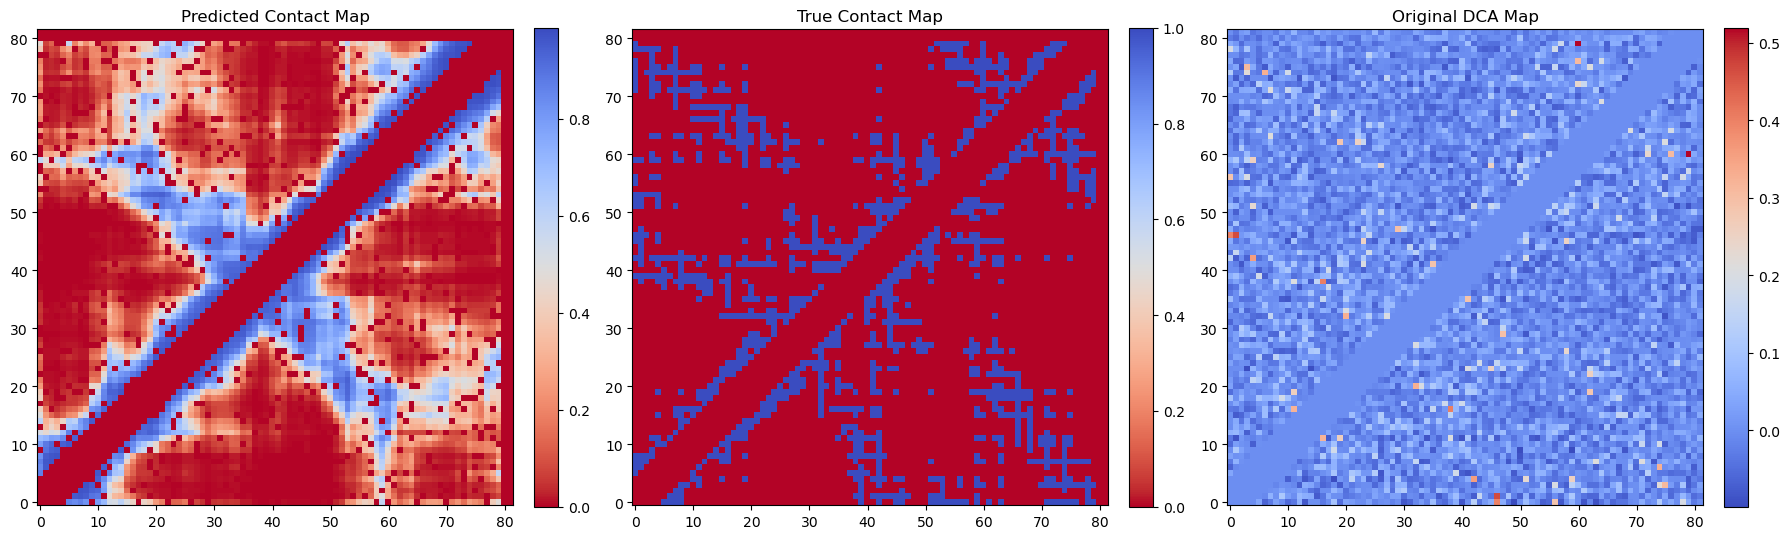

In [28]:
pos=79


i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)

mask = batch.edge_mask #& batch.pair_mask

scores = torch.sigmoid(pred_logits.squeeze(-1))
pred_contact_map = graph_to_matrix(batch, scores.cpu(), mask.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu(),mask.cpu())
original_dca_map = graph_to_matrix(batch, batch.edge_attr.cpu())


fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---


im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original DCA Map ---
im2 = axes[2].imshow(original_dca_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Original DCA Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()